<a href="https://colab.research.google.com/github/rfaoktvian/Dicoding_FinalProject/blob/main/Nazly_Rafa_Oktafian_Nuzqu_Proyek_Klasifikasi_Gambar_Dicoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Latar Belakang

Proyek ini bertujuan membangun model *Convolutional Neural Network* (CNN) untuk mengklasifikasikan gambar pemandangan alam menggunakan **Intel Image Classification Dataset**. Dataset ini terdiri dari sekitar 25.000 gambar berukuran 150×150 piksel yang terbagi ke dalam 6 kategori: *buildings*, *forest*, *glacier*, *mountain*, *sea*, dan *street*.

Model dibangun menggunakan arsitektur Sequential dengan lapisan Conv2D dan Pooling, kemudian dievaluasi pada data train dan test dengan target akurasi minimal 85%. Model akhir akan disimpan dalam format SavedModel, TF-Lite, dan TensorFlow.js untuk keperluan deployment di berbagai platform.

## IMPORT LIBRARY

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from google.colab import drive

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## LOAD DATASET

In [3]:
drive.mount('/content/drive')
base_dir   = '/content/drive/MyDrive/Dicoding/FinalProject/ProyeksiGambar/Intel_Classification/'

def detect_path(base, folder):
    nested = os.path.join(base, folder, folder)
    if os.path.isdir(nested):
        return nested
    direct = os.path.join(base, folder)
    if os.path.isdir(direct):
        return direct
    raise FileNotFoundError(f"Folder '{folder}' tidak ditemukan di {base}")

TRAIN_PATH = detect_path(base_dir, 'seg_train')
TEST_PATH  = detect_path(base_dir, 'seg_test')

print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH :", TEST_PATH)

Mounted at /content/drive
TRAIN_PATH: /content/drive/MyDrive/Dicoding/FinalProject/ProyeksiGambar/Intel_Classification/seg_train/seg_train
TEST_PATH : /content/drive/MyDrive/Dicoding/FinalProject/ProyeksiGambar/Intel_Classification/seg_test/seg_test


In [4]:
print("\nStruktur folder:")
for item in sorted(os.listdir(TRAIN_PATH)):
    count = len(os.listdir(os.path.join(TRAIN_PATH, item)))
    print(f"  {item}/  → {count} gambar")


Struktur folder:
  buildings/  → 2191 gambar
  forest/  → 2271 gambar
  glacier/  → 2404 gambar
  mountain/  → 2512 gambar
  sea/  → 2274 gambar
  street/  → 2382 gambar


In [5]:
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32
SEED       = 42
EPOCHS     = 30

CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
NUM_CLASSES = len(CLASS_NAMES)

print(f"Jumlah kelas  : {NUM_CLASSES}")
print(f"Ukuran gambar : {IMG_SIZE}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Max epochs    : {EPOCHS}")

Jumlah kelas  : 6
Ukuran gambar : (150, 150)
Batch size    : 32
Max epochs    : 30


In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

print(f"\nKelas terdeteksi : {train_dataset.class_names}")
print(f"Batch train      : {len(train_dataset)}")
print(f"Batch val        : {len(val_dataset)}")
print(f"Batch test       : {len(test_dataset)}")

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.

Kelas terdeteksi : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Batch train      : 351
Batch val        : 88
Batch test       : 94


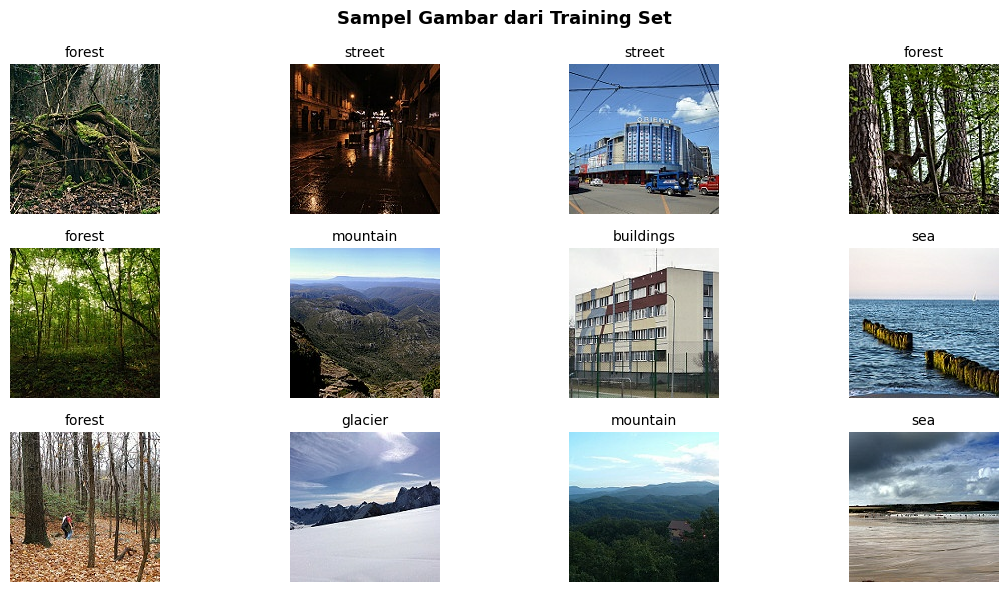

In [7]:
plt.figure(figsize=(12, 6))
for images, labels in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = np.argmax(labels[i])
        plt.title(CLASS_NAMES[label_idx], fontsize=10)
        plt.axis("off")
plt.suptitle("Sampel Gambar dari Training Set", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
normalization_layer = layers.Rescaling(1./255)

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")
def preprocess_train(images, labels):
    images = data_augmentation(images, training=True)
    images = normalization_layer(images)
    return images, labels

def preprocess_eval(images, labels):
    images = normalization_layer(images)
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_dataset.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_dataset.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_dataset.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Preprocessing selesai.")

Preprocessing selesai.


In [10]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name="Intel_CNN")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Intel_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,010,758 (42.00 MB)

 Trainable params: 11,009,798 (42.00 MB)

 Non-trainable params: 960 (3.75 KB)